# Target E-Commerce — Data Analysis


##  1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

##  2. Load Data from CSV Files

In [2]:
BASE_PATH = "C:/Users/PARTH/Downloads/drive-download-20260417T042949Z-3-001/csv/"

customers   = pd.read_csv(BASE_PATH + "customers.csv")
orders      = pd.read_csv(BASE_PATH + "orders.csv")
payments    = pd.read_csv(BASE_PATH + "payments.csv")
order_items = pd.read_csv(BASE_PATH + "order_items.csv")
products    = pd.read_csv(BASE_PATH + "products.csv")
sellers     = pd.read_csv(BASE_PATH + "sellers.csv", encoding='latin1')
geolocation = pd.read_csv(BASE_PATH + "geolocation.csv")

print("Tables loaded successfully!")
for name, df in [("customers", customers), ("orders", orders), ("payments", payments),
                 ("order_items", order_items), ("products", products),
                 ("sellers", sellers), ("geolocation", geolocation)]:
    print(f"  {name:<15} {df.shape[0]:>8,} rows  x  {df.shape[1]} cols")

Tables loaded successfully!
  customers         99,441 rows  x  5 cols
  orders            99,441 rows  x  8 cols
  payments         103,886 rows  x  5 cols
  order_items      112,650 rows  x  7 cols
  products          32,951 rows  x  9 cols
  sellers            3,095 rows  x  4 cols
  geolocation     1,000,163 rows  x  5 cols



##  3. Timestamp Conversion


### 3a. Before — orders dtypes

In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


### 3b. Convert timestamp columns — orders

In [47]:
timestamp_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in timestamp_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print(" orders — timestamp conversion complete")
orders[timestamp_cols_orders].dtypes

 orders — timestamp conversion complete


order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

### 3c. Convert timestamp column — order_items

In [48]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')

print(" order_items — timestamp conversion complete")
print(f"   shipping_limit_date dtype: {order_items['shipping_limit_date'].dtype}")

 order_items — timestamp conversion complete
   shipping_limit_date dtype: datetime64[ns]


### 3d. After — orders dtypes (verify)

In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB



##  4. Data Cleaning — All Tables

### 4a. customers

In [7]:
print("=== customers — Before Cleaning ===")
print(f"Shape        : {customers.shape}")
print(f"Duplicates   : {customers.duplicated().sum()}")
print(f"Null values  :\n{customers.isnull().sum()}")

=== customers — Before Cleaning ===
Shape        : (99441, 5)
Duplicates   : 0
Null values  :
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [8]:
# Drop exact duplicate rows
customers.drop_duplicates(inplace=True)

# Drop rows where primary key is null
customers.dropna(subset=['customer_id'], inplace=True)

# Standardise text — strip whitespace, lowercase city, uppercase state
customers['customer_city']  = customers['customer_city'].str.strip().str.lower()
customers['customer_state'] = customers['customer_state'].str.strip().str.upper()

print("=== customers — After Cleaning ===")
print(f"Shape        : {customers.shape}")
print(f"Duplicates   : {customers.duplicated().sum()}")
print(f"Null values  :\n{customers.isnull().sum()}")
customers.head(3)

=== customers — After Cleaning ===
Shape        : (99441, 5)
Duplicates   : 0
Null values  :
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


### 4b. orders

In [9]:
print("=== orders — Before Cleaning ===")
print(f"Shape        : {orders.shape}")
print(f"Duplicates   : {orders.duplicated().sum()}")
print(f"Null values  :\n{orders.isnull().sum()}")

=== orders — Before Cleaning ===
Shape        : (99441, 8)
Duplicates   : 0
Null values  :
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [10]:
# Drop exact duplicates
orders.drop_duplicates(inplace=True)

# Drop rows missing the critical purchase timestamp (can't do time-based analysis without it)
orders.dropna(subset=['order_purchase_timestamp'], inplace=True)

# Remove future-dated purchase timestamps (data quality guard)
orders = orders[orders['order_purchase_timestamp'] <= pd.Timestamp.now()]

# Add helper date columns for analysis
orders['year']  = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month
orders['month_name'] = orders['order_purchase_timestamp'].dt.strftime('%b')

# Standardise order_status text
orders['order_status'] = orders['order_status'].str.strip().str.lower()

print("=== orders — After Cleaning ===")
print(f"Shape        : {orders.shape}")
print(f"Duplicates   : {orders.duplicated().sum()}")
print(f"Null values  :\n{orders.isnull().sum()}")
orders.head(3)

=== orders — After Cleaning ===
Shape        : (99441, 11)
Duplicates   : 0
Null values  :
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
year                                0
month                               0
month_name                          0
dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,month_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,Oct
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,Jul
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,Aug


### 4c. payments

In [11]:
print("=== payments — Before Cleaning ===")
print(f"Shape        : {payments.shape}")
print(f"Duplicates   : {payments.duplicated().sum()}")
print(f"Null values  :\n{payments.isnull().sum()}")

=== payments — Before Cleaning ===
Shape        : (103886, 5)
Duplicates   : 0
Null values  :
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [12]:
# Drop exact duplicates
payments.drop_duplicates(inplace=True)

# Ensure numeric types are correct
payments['payment_value']        = pd.to_numeric(payments['payment_value'], errors='coerce')
payments['payment_installments'] = pd.to_numeric(payments['payment_installments'], errors='coerce')

# Drop rows with null or zero/negative payment value
payments.dropna(subset=['payment_value'], inplace=True)
payments = payments[payments['payment_value'] > 0]

# Standardise payment_type text
payments['payment_type'] = payments['payment_type'].str.strip().str.lower()

print("=== payments — After Cleaning ===")
print(f"Shape        : {payments.shape}")
print(f"Duplicates   : {payments.duplicated().sum()}")
print(f"Null values  :\n{payments.isnull().sum()}")
print(f"\nUnique payment types: {payments['payment_type'].unique()}")
payments.head(3)

=== payments — After Cleaning ===
Shape        : (103877, 5)
Duplicates   : 0
Null values  :
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Unique payment types: ['credit_card' 'upi' 'voucher' 'debit_card']


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


### 4d. order_items

In [13]:
print("=== order_items — Before Cleaning ===")
print(f"Shape        : {order_items.shape}")
print(f"Duplicates   : {order_items.duplicated().sum()}")
print(f"Null values  :\n{order_items.isnull().sum()}")

=== order_items — Before Cleaning ===
Shape        : (112650, 7)
Duplicates   : 0
Null values  :
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [14]:
# Drop exact duplicates
order_items.drop_duplicates(inplace=True)

# Drop rows with null in critical columns
order_items.dropna(subset=['order_id', 'product_id', 'seller_id'], inplace=True)

# Remove rows with non-positive price or freight_value
order_items = order_items[order_items['price'] > 0]
order_items = order_items[order_items['freight_value'] >= 0]

# Drop rows where shipping_limit_date could not be parsed
order_items.dropna(subset=['shipping_limit_date'], inplace=True)

print("=== order_items — After Cleaning ===")
print(f"Shape        : {order_items.shape}")
print(f"Duplicates   : {order_items.duplicated().sum()}")
print(f"Null values  :\n{order_items.isnull().sum()}")
order_items.head(3)

=== order_items — After Cleaning ===
Shape        : (112650, 7)
Duplicates   : 0
Null values  :
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


### 4e. products

In [15]:
print("=== products — Before Cleaning ===")
print(f"Shape        : {products.shape}")
print(f"Duplicates   : {products.duplicated().sum()}")
print(f"Null values  :\n{products.isnull().sum()}")

=== products — Before Cleaning ===
Shape        : (32951, 9)
Duplicates   : 0
Null values  :
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [16]:
# Rename the column with a space in its name for safety
products.rename(columns={'product category': 'product_category'}, inplace=True)

# Drop exact duplicates
products.drop_duplicates(inplace=True)

# Drop rows missing product_id (primary key)
products.dropna(subset=['product_id'], inplace=True)

# Standardise category text
products['product_category'] = products['product_category'].str.strip().str.lower()

# Fill missing category with 'unknown'
products['product_category'] = products['product_category'].fillna('unknown')

# Fill missing physical dimensions with median (reasonable imputation for measurements)
dim_cols = ['product_name_length', 'product_description_length', 'product_photos_qty',
            'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dim_cols:
    products[col] = products[col].fillna(products[col].median())

print("=== products — After Cleaning ===")
print(f"Shape        : {products.shape}")
print(f"Duplicates   : {products.duplicated().sum()}")
print(f"Null values  :\n{products.isnull().sum()}")
products.head(3)

=== products — After Cleaning ===
Shape        : (32951, 9)
Duplicates   : 0
Null values  :
product_id                    0
product_category              0
product_name_length           0
product_description_length    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


,product_id,product_category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sport leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0


### 4f. sellers

In [17]:
print("=== sellers — Before Cleaning ===")
print(f"Shape        : {sellers.shape}")
print(f"Duplicates   : {sellers.duplicated().sum()}")
print(f"Null values  :\n{sellers.isnull().sum()}")

=== sellers — Before Cleaning ===
Shape        : (3095, 4)
Duplicates   : 0
Null values  :
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [18]:
# Drop exact duplicates
sellers.drop_duplicates(inplace=True)

# Drop rows missing seller_id
sellers.dropna(subset=['seller_id'], inplace=True)

# Standardise text
sellers['seller_city']  = sellers['seller_city'].str.strip().str.lower()
sellers['seller_state'] = sellers['seller_state'].str.strip().str.upper()

print("=== sellers — After Cleaning ===")
print(f"Shape        : {sellers.shape}")
print(f"Duplicates   : {sellers.duplicated().sum()}")
print(f"Null values  :\n{sellers.isnull().sum()}")
sellers.head(3)

=== sellers — After Cleaning ===
Shape        : (3095, 4)
Duplicates   : 0
Null values  :
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


### 4g. geolocation

In [19]:
print("=== geolocation — Before Cleaning ===")
print(f"Shape        : {geolocation.shape}")
print(f"Duplicates   : {geolocation.duplicated().sum()}")
print(f"Null values  :\n{geolocation.isnull().sum()}")

=== geolocation — Before Cleaning ===
Shape        : (1000163, 5)
Duplicates   : 261831
Null values  :
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


In [20]:
# Drop exact duplicate rows
geolocation.drop_duplicates(inplace=True)

# Drop rows with null lat/lng
geolocation.dropna(subset=['geolocation_lat', 'geolocation_lng'], inplace=True)

# Remove rows with out-of-range lat/lng for Brazil
# Brazil bounding box: lat [-33.75, 5.27], lng [-73.99, -28.84]
geolocation = geolocation[
    (geolocation['geolocation_lat'].between(-33.75, 5.27)) &
    (geolocation['geolocation_lng'].between(-73.99, -28.84))
]

# Standardise text
geolocation['geolocation_city']  = geolocation['geolocation_city'].str.strip().str.lower()
geolocation['geolocation_state'] = geolocation['geolocation_state'].str.strip().str.upper()

print("=== geolocation — After Cleaning ===")
print(f"Shape        : {geolocation.shape}")
print(f"Duplicates   : {geolocation.duplicated().sum()}")
print(f"Null values  :\n{geolocation.isnull().sum()}")
geolocation.head(3)

=== geolocation — After Cleaning ===
Shape        : (738305, 5)
Duplicates   : 0
Null values  :
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



## 5. Analysis & Visualization



###  BASIC — B1. Unique cities where customers are located (Top 15)

Total unique cities: 4119


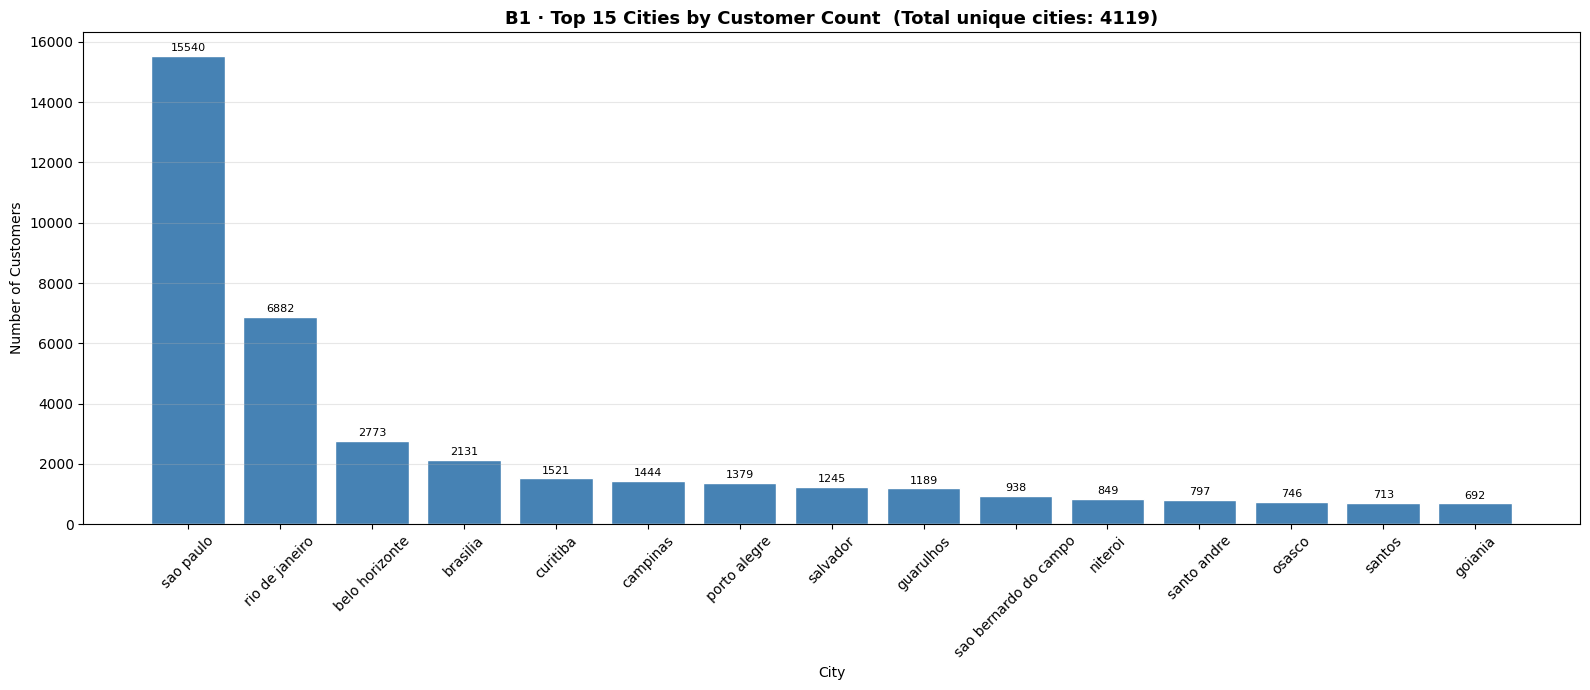

In [44]:
unique_cities = customers['customer_city'].nunique()
print(f"Total unique cities: {unique_cities}")

top_cities = customers['customer_city'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(top_cities.index, top_cities.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, fontsize=8, padding=2)
ax.set_title(f'B1 · Top 15 Cities by Customer Count  (Total unique cities: {unique_cities})', fontsize=13, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###  BASIC — B2. Number of orders placed in 2017 (monthly breakdown)

Total orders in 2017: 45,101


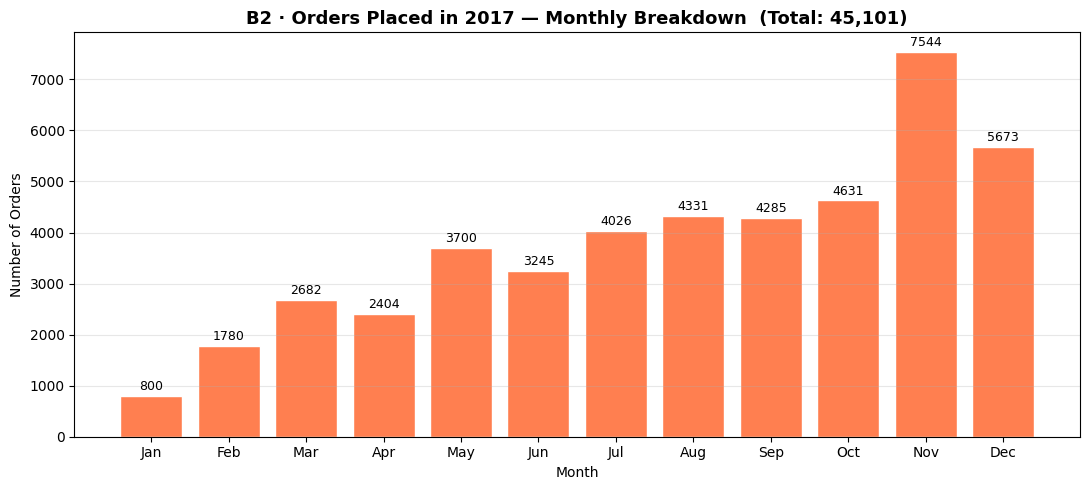

In [22]:
orders_2017 = orders[orders['year'] == 2017]
monthly_2017 = orders_2017.groupby('month').size().reindex(range(1, 13), fill_value=0)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(f"Total orders in 2017: {len(orders_2017):,}")

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(month_labels, monthly_2017.values, color='coral', edgecolor='white')
ax.bar_label(bars, fontsize=9, padding=2)
ax.set_title(f'B2 · Orders Placed in 2017 — Monthly Breakdown  (Total: {len(orders_2017):,})', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###  BASIC — B3. Total sales per category

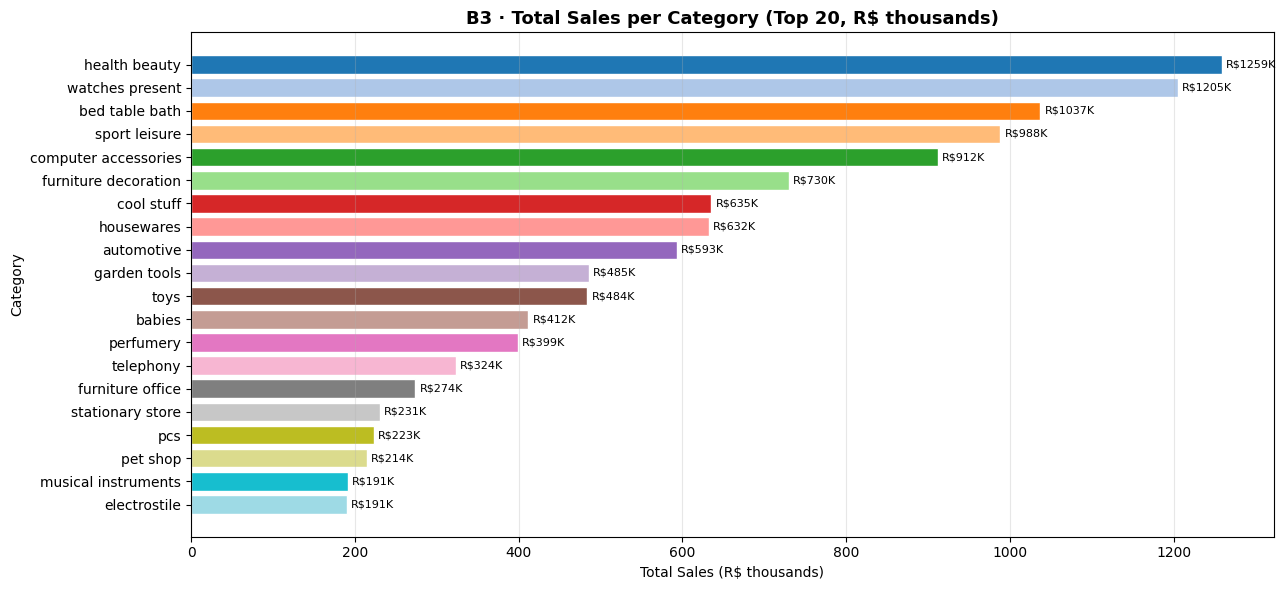

In [23]:
items_with_cat = order_items.merge(products[['product_id', 'product_category']], on='product_id', how='left')
cat_sales = items_with_cat.groupby('product_category')['price'].sum().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.tab20.colors[:len(cat_sales)]
bars = ax.barh(cat_sales.index[::-1], cat_sales.values[::-1] / 1e3, color=colors[::-1], edgecolor='white')
ax.bar_label(bars, fmt='R$%.0fK', fontsize=8, padding=3)
ax.set_title('B3 · Total Sales per Category (Top 20, R$ thousands)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Sales (R$ thousands)')
ax.set_ylabel('Category')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

###  BASIC — B4. Percentage of orders paid in installments

Installment orders  : 51,338 (49.4%)
Single-pay orders   : 52,537 (50.6%)


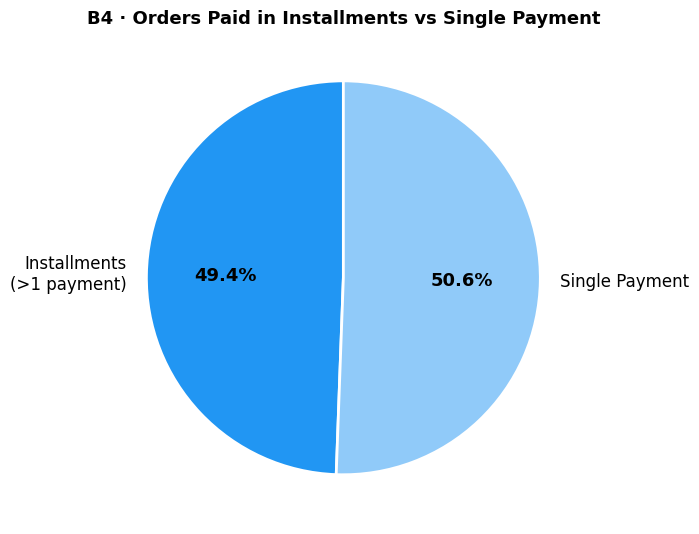

In [24]:
installment_orders = (payments['payment_installments'] > 1).sum()
single_orders      = (payments['payment_installments'] == 1).sum()
pct_installments   = installment_orders / len(payments) * 100

print(f"Installment orders  : {installment_orders:,} ({pct_installments:.1f}%)")
print(f"Single-pay orders   : {single_orders:,} ({100 - pct_installments:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [pct_installments, 100 - pct_installments],
    labels=['Installments\n(>1 payment)', 'Single Payment'],
    colors=['#2196F3', '#90CAF9'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=12)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax.set_title('B4 · Orders Paid in Installments vs Single Payment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  BASIC — B5. Number of customers from each state

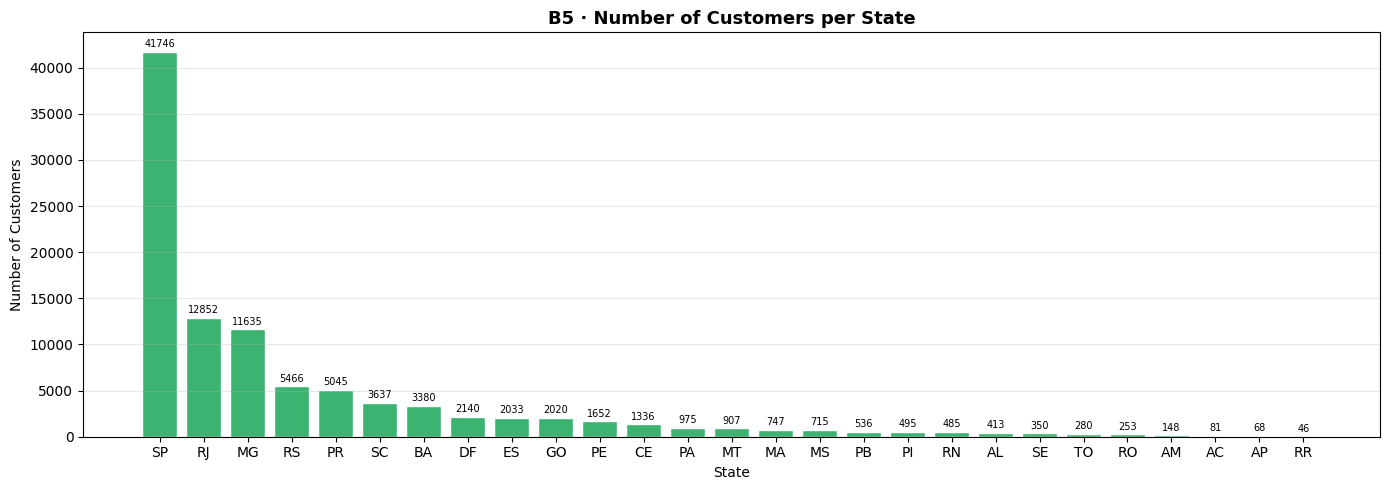

In [25]:
state_customers = customers.groupby('customer_state').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(state_customers.index, state_customers.values, color='mediumseagreen', edgecolor='white')
ax.bar_label(bars, fontsize=7, padding=2)
ax.set_title('B5 · Number of Customers per State', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Number of Customers')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
###  INTERMEDIATE — I1. Number of orders per month in 2018

Total orders in 2018: 54,011


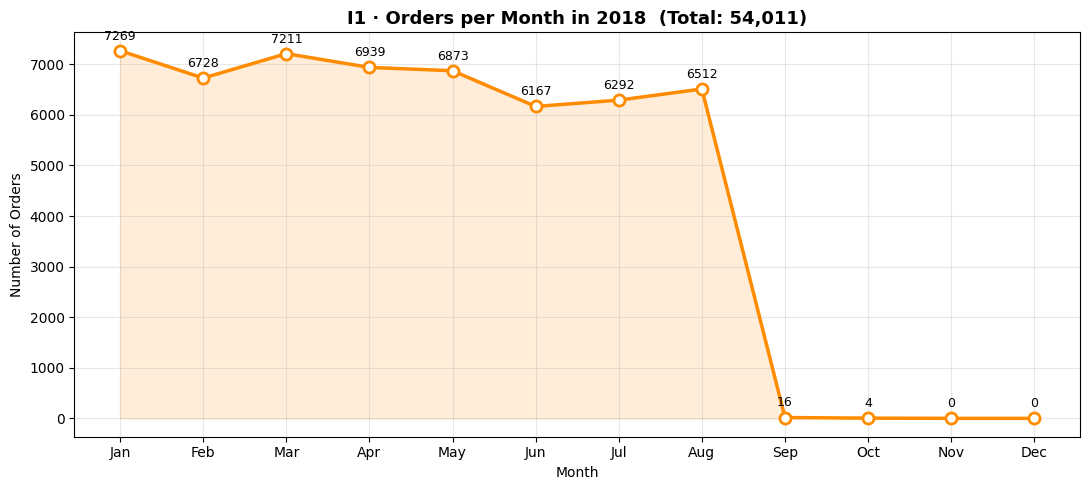

In [26]:
orders_2018   = orders[orders['year'] == 2018]
monthly_2018  = orders_2018.groupby('month').size().reindex(range(1, 13), fill_value=0)

print(f"Total orders in 2018: {len(orders_2018):,}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(month_labels, monthly_2018.values, marker='o', linewidth=2.5,
        color='darkorange', markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(month_labels, monthly_2018.values, alpha=0.15, color='darkorange')
for i, v in enumerate(monthly_2018.values):
    ax.annotate(str(v), (month_labels[i], v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
ax.set_title(f'I1 · Orders per Month in 2018  (Total: {len(orders_2018):,})', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###  INTERMEDIATE — I2. Average number of products per order, grouped by customer city (Top 15)

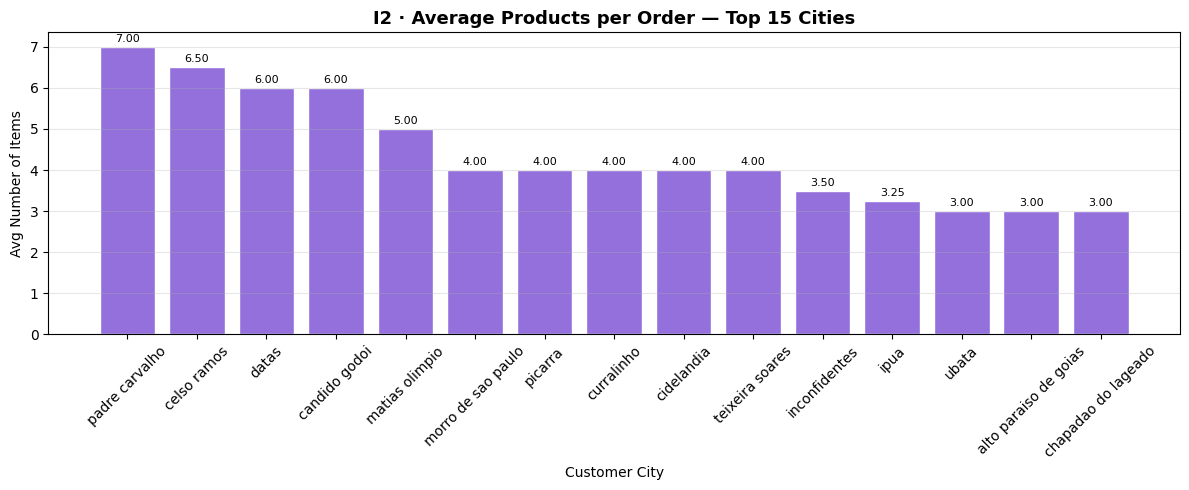

In [27]:
items_per_order = order_items.groupby('order_id').size().reset_index(name='n_items')
orders_with_city = orders.merge(customers[['customer_id', 'customer_city']], on='customer_id', how='left')
orders_with_city = orders_with_city.merge(items_per_order, on='order_id', how='left')

city_avg_items = (orders_with_city.groupby('customer_city')['n_items']
                  .mean().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(city_avg_items.index, city_avg_items.values, color='mediumpurple', edgecolor='white')
ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
ax.set_title('I2 · Average Products per Order — Top 15 Cities', fontsize=13, fontweight='bold')
ax.set_xlabel('Customer City')
ax.set_ylabel('Avg Number of Items')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###  INTERMEDIATE — I3. Percentage of total revenue contributed by each product category (Top 12)

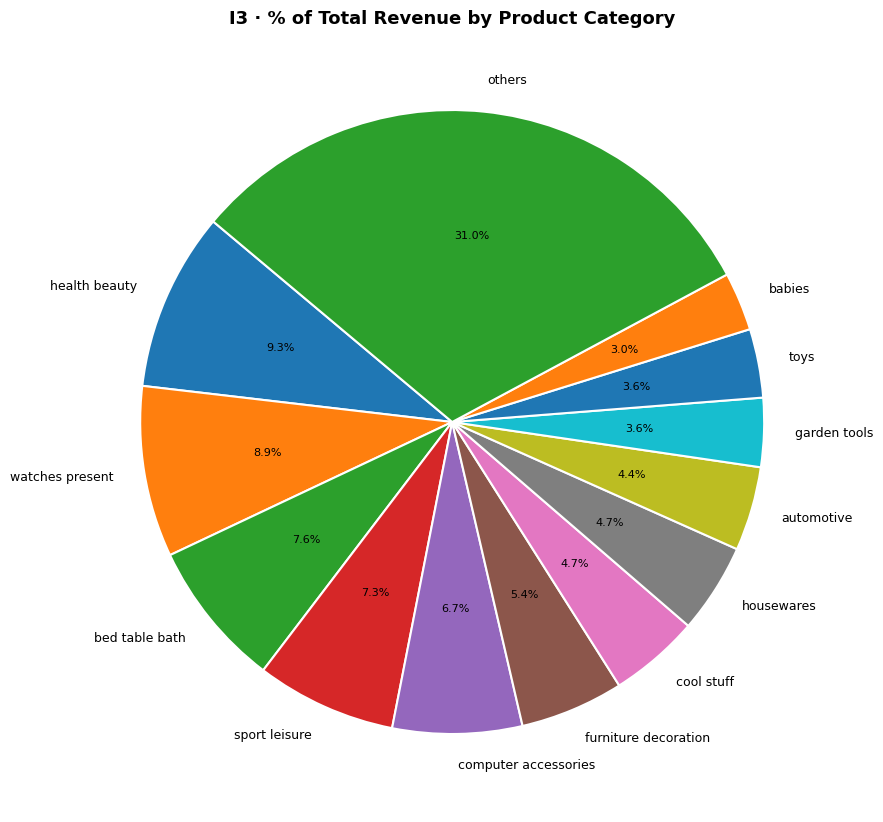

In [28]:
cat_revenue     = items_with_cat.groupby('product_category')['price'].sum()
cat_rev_pct     = (cat_revenue / cat_revenue.sum() * 100).sort_values(ascending=False)
top12           = cat_rev_pct.head(12)
others          = cat_rev_pct.iloc[12:].sum()
plot_data       = pd.concat([top12, pd.Series({'others': others})])

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    plot_data.values,
    labels=plot_data.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=9)
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('I3 · % of Total Revenue by Product Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  INTERMEDIATE — I4. Correlation between product price and purchase frequency

Pearson correlation (price vs frequency): -0.0321


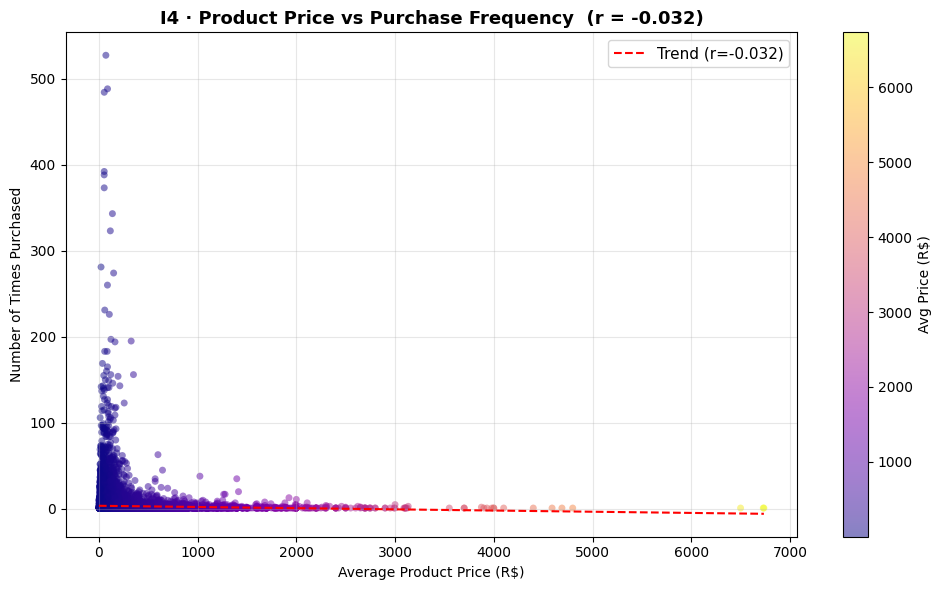

In [29]:
product_freq  = order_items.groupby('product_id').size().reset_index(name='purchase_count')
product_price = order_items.groupby('product_id')['price'].mean().reset_index(name='avg_price')
price_freq    = product_freq.merge(product_price, on='product_id')
corr          = price_freq['avg_price'].corr(price_freq['purchase_count'])

print(f"Pearson correlation (price vs frequency): {corr:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(price_freq['avg_price'], price_freq['purchase_count'],
                alpha=0.5, s=25, c=price_freq['avg_price'], cmap='plasma', edgecolors='none')
plt.colorbar(sc, ax=ax, label='Avg Price (R$)')
# Trend line
m, b = np.polyfit(price_freq['avg_price'], price_freq['purchase_count'], 1)
x_line = np.linspace(price_freq['avg_price'].min(), price_freq['avg_price'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--', label=f'Trend (r={corr:.3f})')
ax.legend(fontsize=11)
ax.set_title(f'I4 · Product Price vs Purchase Frequency  (r = {corr:.3f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Product Price (R$)')
ax.set_ylabel('Number of Times Purchased')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###  INTERMEDIATE — I5. Total revenue per seller — Top 15 ranked

 rank                        seller_id  total_revenue
    1 4869f7a5dfa277a7dca6462dcf3b52b2      229472.63
    2 53243585a1d6dc2643021fd1853d8905      222776.05
    3 4a3ca9315b744ce9f8e9374361493884      200472.92
    4 fa1c13f2614d7b5c4749cbc52fecda94      194042.03
    5 7c67e1448b00f6e969d365cea6b010ab      187923.89
    6 7e93a43ef30c4f03f38b393420bc753a      176431.87
    7 da8622b14eb17ae2831f4ac5b9dab84a      160236.57
    8 7a67c85e85bb2ce8582c35f2203ad736      141745.53
    9 1025f0e2d44d7041d6cf58b6550e0bfa      138968.55
   10 955fee9216a65b617aa5c0531780ce60      135171.70
   11 46dc3b2cc0980fb8ec44634e21d2718e      128111.19
   12 6560211a19b47992c3666cc44a7e94c0      123304.83
   13 620c87c171fb2a6dd6e8bb4dec959fc6      114774.50
   14 7d13fca15225358621be4086e1eb0964      113628.97
   15 5dceca129747e92ff8ef7a997dc4f8ca      112155.53


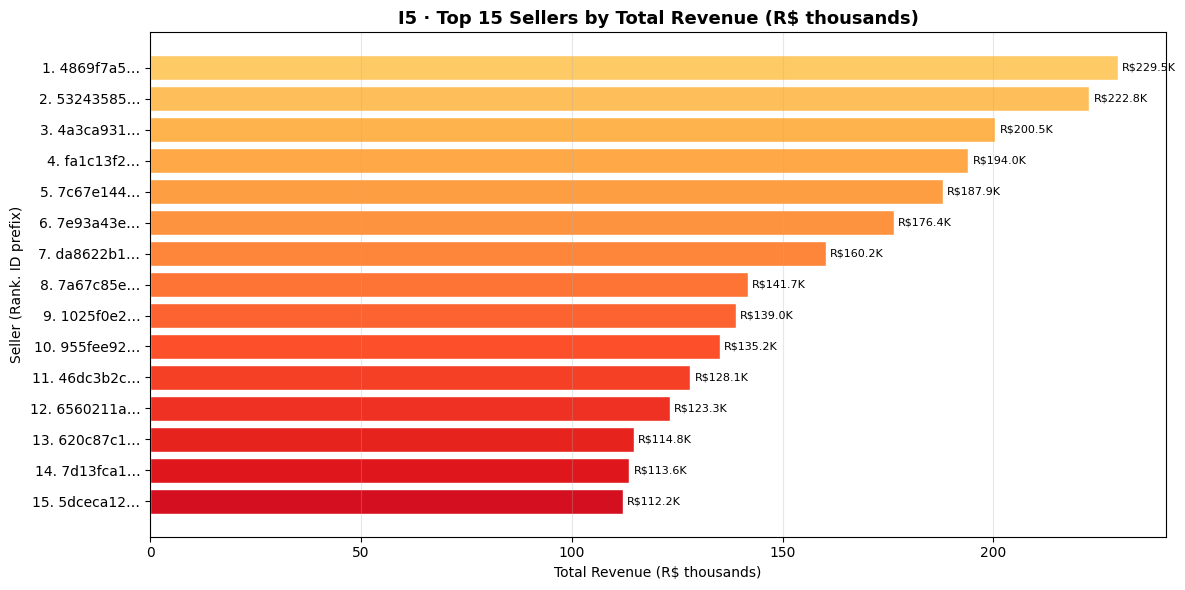

In [30]:
seller_revenue = (order_items.groupby('seller_id')['price']
                  .sum().sort_values(ascending=False).head(15).reset_index())
seller_revenue.columns = ['seller_id', 'total_revenue']
seller_revenue['rank'] = range(1, len(seller_revenue) + 1)
seller_revenue['label'] = seller_revenue['rank'].astype(str) + '. ' + seller_revenue['seller_id'].str[:8] + '…'

print(seller_revenue[['rank', 'seller_id', 'total_revenue']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.8, 0.3, len(seller_revenue)))
bars = ax.barh(seller_revenue['label'][::-1], seller_revenue['total_revenue'][::-1] / 1e3,
               color=colors, edgecolor='white')
ax.bar_label(bars, fmt='R$%.1fK', fontsize=8, padding=3)
ax.set_title('I5 · Top 15 Sellers by Total Revenue (R$ thousands)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (R$ thousands)')
ax.set_ylabel('Seller (Rank. ID prefix)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


###  ADVANCED — A1. Moving average of order values for each customer (Top 5 most active)

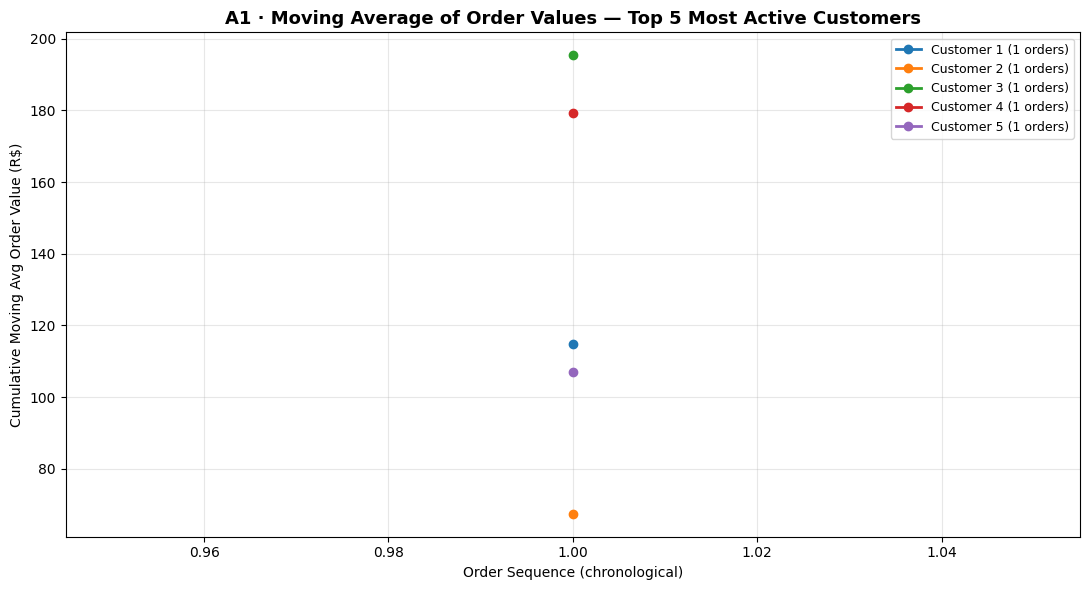

In [31]:
order_totals = payments.groupby('order_id')['payment_value'].sum().reset_index()
cust_orders  = (orders[['order_id', 'customer_id', 'order_purchase_timestamp']]
                .merge(order_totals, on='order_id')
                .sort_values(['customer_id', 'order_purchase_timestamp']))

top5_custs = cust_orders['customer_id'].value_counts().head(5).index

fig, ax = plt.subplots(figsize=(11, 6))
palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
for i, cid in enumerate(top5_custs):
    sub = cust_orders[cust_orders['customer_id'] == cid].copy().reset_index(drop=True)
    sub['moving_avg'] = sub['payment_value'].expanding().mean()
    ax.plot(sub.index + 1, sub['moving_avg'], marker='o', markersize=6,
            linewidth=2, color=palette[i], label=f'Customer {i+1} ({len(sub)} orders)')
    ax.plot(sub.index + 1, sub['payment_value'], alpha=0.2, linewidth=1,
            color=palette[i], linestyle='--')
ax.set_title('A1 · Moving Average of Order Values — Top 5 Most Active Customers', fontsize=13, fontweight='bold')
ax.set_xlabel('Order Sequence (chronological)')
ax.set_ylabel('Cumulative Moving Avg Order Value (R$)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###  ADVANCED — A2. Cumulative sales per month for each year

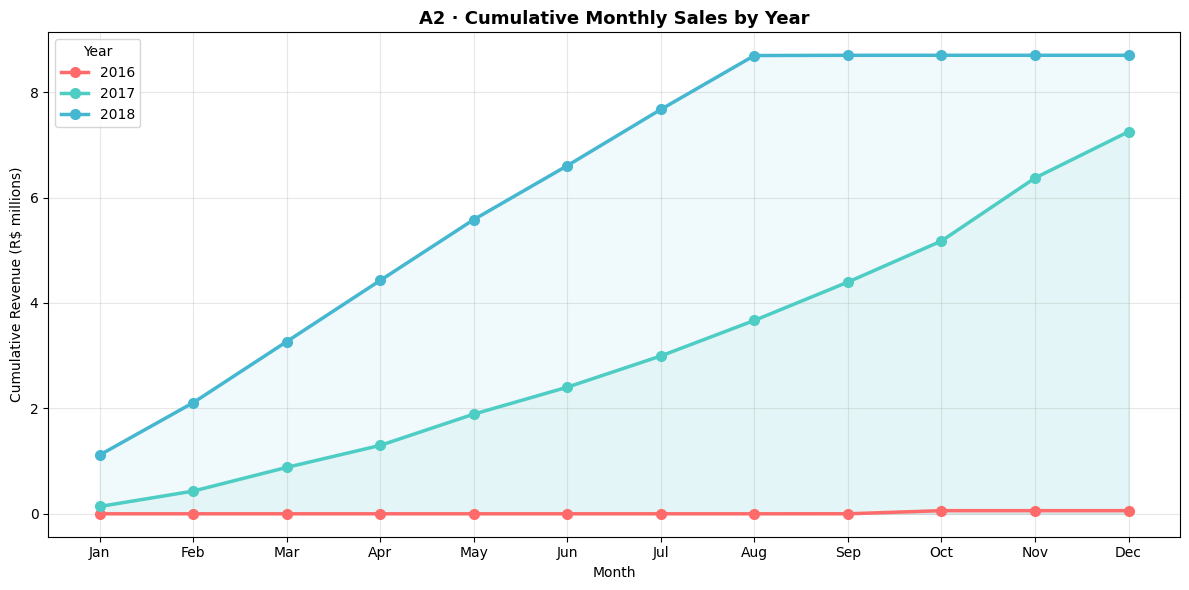

In [32]:
order_rev = (orders[['order_id', 'year', 'month']]
             .merge(order_totals, on='order_id', how='left'))
monthly_rev = order_rev.groupby(['year', 'month'])['payment_value'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
year_colors = {2016: '#FF6B6B', 2017: '#4ECDC4', 2018: '#45B7D1'}
for yr in sorted(monthly_rev['year'].unique()):
    sub = monthly_rev[monthly_rev['year'] == yr].sort_values('month')
    sub = sub.set_index('month').reindex(range(1, 13), fill_value=0).reset_index()
    sub['cumulative'] = sub['payment_value'].cumsum()
    ax.plot(month_labels, sub['cumulative'] / 1e6, marker='o', markersize=7,
            linewidth=2.5, color=year_colors.get(yr, 'gray'), label=str(yr))
    ax.fill_between(month_labels, sub['cumulative'] / 1e6, alpha=0.08,
                    color=year_colors.get(yr, 'gray'))
ax.set_title('A2 · Cumulative Monthly Sales by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Revenue (R$ millions)')
ax.legend(title='Year', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###  ADVANCED — A3. Year-over-Year growth rate of total sales

Annual Revenue & YoY Growth:
  2016: R$       59,362   YoY Growth: N/A (base year)
  2017: R$    7,249,747   YoY Growth: +12112.7%
  2018: R$    8,699,763   YoY Growth: +20.0%


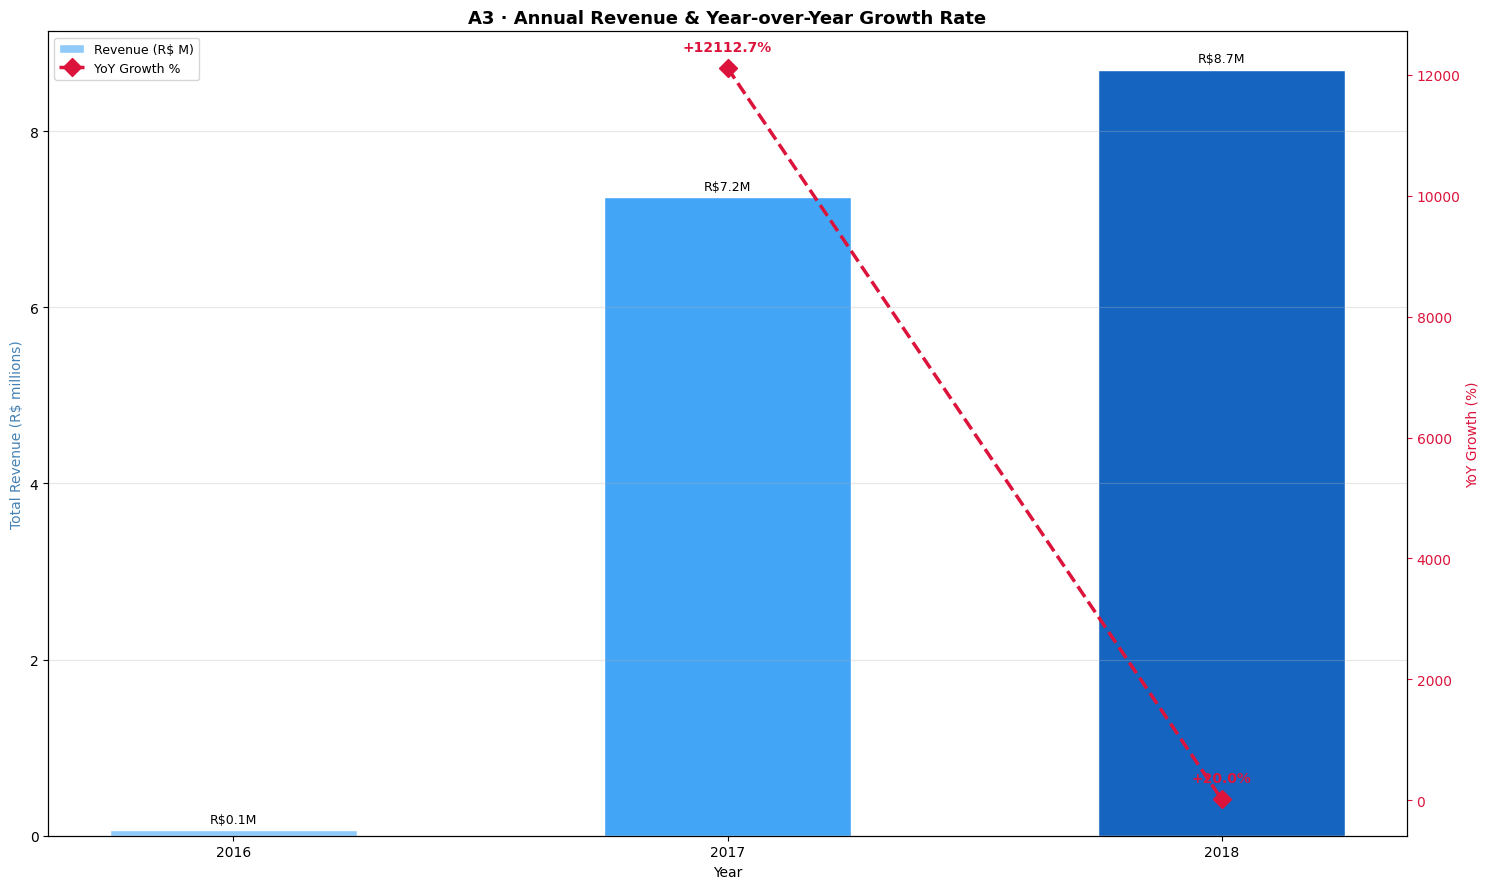

In [46]:
annual_rev = order_rev.groupby('year')['payment_value'].sum()
yoy_growth = annual_rev.pct_change() * 100

print("Annual Revenue & YoY Growth:")
for yr in annual_rev.index:
    g = yoy_growth[yr]
    g_str = f"{g:+.1f}%" if not np.isnan(g) else "N/A (base year)"
    print(f"  {yr}: R$ {annual_rev[yr]:>12,.0f}   YoY Growth: {g_str}")

fig, ax1 = plt.subplots(figsize=(15, 9))
x = [str(y) for y in annual_rev.index]
bars = ax1.bar(x, annual_rev.values / 1e6, color=['#90CAF9','#42A5F5','#1565C0'][:len(x)],
               edgecolor='white', width=0.5, label='Revenue (R$ M)')
ax1.bar_label(bars, fmt='R$%.1fM', fontsize=9, padding=3)
ax1.set_ylabel('Total Revenue (R$ millions)', color='steelblue')
ax1.set_xlabel('Year')

ax2 = ax1.twinx()
yoy_vals = yoy_growth.dropna()
ax2.plot([str(y) for y in yoy_vals.index], yoy_vals.values,
         color='crimson', linewidth=2.5, marker='D', markersize=9,
         linestyle='--', label='YoY Growth %')
for yr, g in yoy_vals.items():
    ax2.annotate(f'{g:+.1f}%', xy=(str(yr), g),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', color='crimson', fontsize=10, fontweight='bold')
ax2.set_ylabel('YoY Growth (%)', color='crimson')
ax2.tick_params(axis='y', colors='crimson')

ax1.set_title('A3 · Annual Revenue & Year-over-Year Growth Rate', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###  ADVANCED — A4. Customer retention rate (re-purchase within 6 months of first purchase)

Total unique customers  : 99,437
Retained (within 6 mo)  : 0
Retention rate          : 0.0%


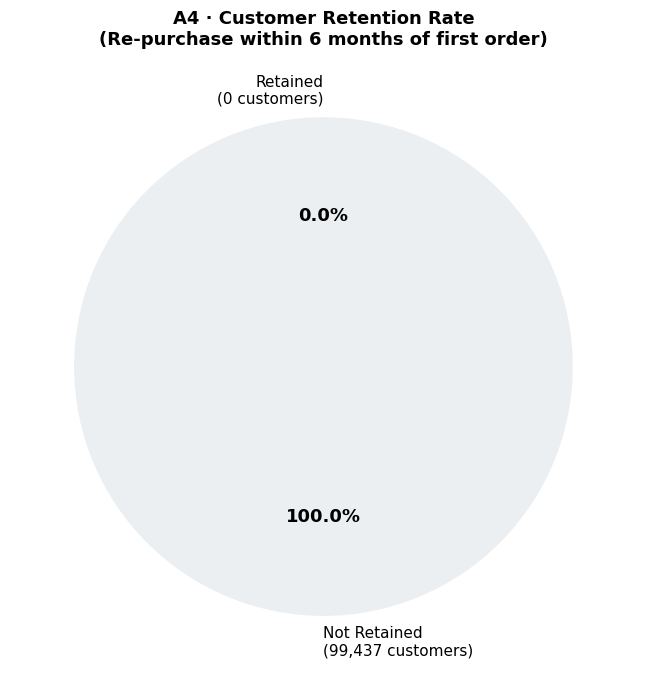

In [34]:
cust_first = (cust_orders.groupby('customer_id')['order_purchase_timestamp']
              .min().reset_index(name='first_purchase'))
cust_all   = cust_orders.merge(cust_first, on='customer_id')
cust_all['days_since_first'] = (cust_all['order_purchase_timestamp'] - cust_all['first_purchase']).dt.days

retained       = cust_all[(cust_all['days_since_first'] > 0) & (cust_all['days_since_first'] <= 180)]['customer_id'].nunique()
total_custs    = cust_all['customer_id'].nunique()
retention_rate = retained / total_custs * 100

print(f"Total unique customers  : {total_custs:,}")
print(f"Retained (within 6 mo)  : {retained:,}")
print(f"Retention rate          : {retention_rate:.1f}%")

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [retention_rate, 100 - retention_rate],
    labels=[f'Retained\n({retained:,} customers)', f'Not Retained\n({total_custs - retained:,} customers)'],
    colors=['#26A69A', '#ECEFF1'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax.set_title('A4 · Customer Retention Rate\n(Re-purchase within 6 months of first order)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  ADVANCED — A5. Top 3 customers who spent the most money in each year

Top 3 Spenders per Year:
 year  rank                      customer_id  payment_value
 2016     1 a9dc96b027d1252bbac0a9b72d837fc6        1423.55
 2016     2 1d34ed25963d5aae4cf3d7f3a4cda173        1400.74
 2016     3 4a06381959b6670756de02e07b83815f        1227.78
 2017     1 1617b1357756262bfa56ab541c47bc16       13664.08
 2017     2 c6e2731c5b391845f6800c97401a43a9        6929.31
 2017     3 3fd6777bbce08a352fddd04e4a7cc8f6        6726.66
 2018     1 ec5b2ba62e574342386871631fafd3fc        7274.88
 2018     2 f48d464a0baaea338cb25f816991ab1f        6922.21
 2018     3 e0a2412720e9ea4f26c1ac985f6a7358        4809.44


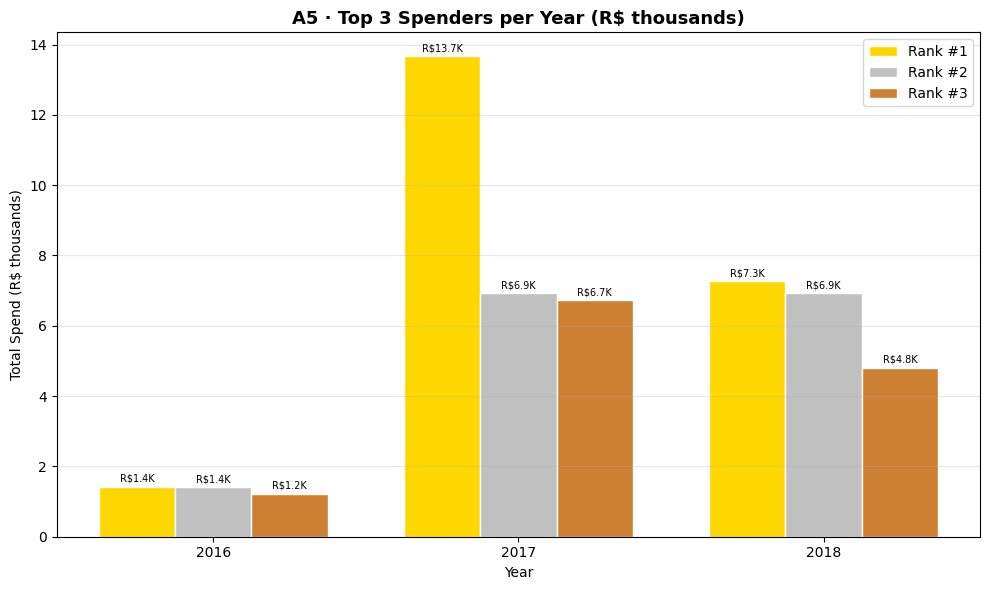

In [35]:
cust_spend = (orders[['order_id', 'customer_id', 'year']]
              .merge(order_totals, on='order_id')
              .groupby(['year', 'customer_id'])['payment_value'].sum().reset_index())

top3_per_year = (cust_spend
                 .sort_values(['year', 'payment_value'], ascending=[True, False])
                 .groupby('year')
                 .head(3)
                 .reset_index(drop=True))
top3_per_year['rank']  = top3_per_year.groupby('year')['payment_value'].rank(ascending=False, method='first').astype(int)
top3_per_year['label'] = '#' + top3_per_year['rank'].astype(str) + '  ' + top3_per_year['customer_id'].str[:10] + '…'

print("Top 3 Spenders per Year:")
print(top3_per_year[['year','rank','customer_id','payment_value']].to_string(index=False))

years_u = sorted(top3_per_year['year'].unique())
rank_colors = {1: '#FFD700', 2: '#C0C0C0', 3: '#CD7F32'}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(years_u))
w = 0.25
for i, rank in enumerate([1, 2, 3]):
    sub = top3_per_year[top3_per_year['rank'] == rank]
    vals = []
    for yr in years_u:
        row = sub[sub['year'] == yr]
        vals.append(row['payment_value'].values[0] if len(row) > 0 else 0)
    bars = ax.bar(x + (i - 1) * w, [v / 1e3 for v in vals], w,
                  label=f'Rank #{rank}', color=rank_colors[rank], edgecolor='white')
    ax.bar_label(bars, fmt='R$%.1fK', fontsize=7, padding=2)

ax.set_title('A5 · Top 3 Spenders per Year (R$ thousands)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Spend (R$ thousands)')
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years_u])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()